In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from alerce.core import Alerce

In [13]:
client = Alerce()
V0332_53 = client.query_objects(
    survey="ztf",
    ra=53.750,
    dec=53.173,
    radius=2
)    

In [14]:
V0332_53

,oid,ndethist,ncovhist,mjdstarthist,mjdendhist,corrected,stellar,ndet,g_r_max,g_r_max_corr,...,lastmjd,deltajd,meanra,meandec,sigmara,sigmadec,class,classifier,probability,step_id_corr
0,ZTF18acbvefj,1317,2032,58096.47294,61076.202604,True,False,938,None,None,...,61076.202604,2653.865289,53.749635,53.173146,0.004074,0.002442,None,None,None,27.5.7a32.dev1


In [15]:
lc = client.query_lightcurve("ZTF18acbvefj", survey="ztf")

In [16]:
lc

{'detections': [{'tid': 'ztf',
   'mjd': 58422.337314799894,
   'candid': '668337311815015009',
   'fid': 2,
   'pid': 668337311815,
   'diffmaglim': 20.002605,
   'isdiffpos': 1,
   'nid': 668,
   'distnr': 0.09415338,
   'magpsf': 17.71181,
   'magpsf_corr': 14.309639,
   'magpsf_corr_ext': None,
   'magap': 18.3012,
   'magap_corr': None,
   'sigmapsf': 0.15717271,
   'sigmapsf_corr': 100.0,
   'sigmapsf_corr_ext': 0.0068471385,
   'sigmagap': 0.0979,
   'sigmagap_corr': None,
   'ra': 53.7495736,
   'dec': 53.1731632,
   'rb': 0.45,
   'rbversion': 't8_f5_c3',
   'drb': 0.0,
   'magapbig': 18.3185,
   'sigmagapbig': 0.1131,
   'rfid': 777120218,
   'has_stamp': False,
   'corrected': True,
   'dubious': False,
   'candid_alert': None,
   'step_id_corr': 'bulk_1.0.0',
   'phase': 0.0,
   'parent_candid': 677280101815015055},
  {'tid': 'ztf',
   'mjd': 58431.28010419989,
   'candid': '677280101815015055',
   'fid': 2,
   'pid': 677280101815,
   'diffmaglim': 19.931068,
   'isdiffpos'

In [20]:
detections_df = pd.DataFrame(lc['detections'])
display(detections_df.head(20))

,tid,mjd,candid,fid,pid,diffmaglim,isdiffpos,nid,distnr,magpsf,...,magapbig,sigmagapbig,rfid,has_stamp,corrected,dubious,candid_alert,step_id_corr,phase,parent_candid
0,ztf,58422.337315,668337311815015009,2,668337311815,20.002605,1,668,0.094153,17.711810,...,18.3185,0.1131,777120218.0,False,True,False,None,bulk_1.0.0,0.0,6.772801e+17
1,ztf,58431.280104,677280101815015055,2,677280101815,19.931068,1,677,0.231997,17.602255,...,17.7125,0.0645,777120218.0,False,True,False,None,bulk_1.0.0,0.0,6.963497e+17
2,ztf,58434.301435,680301431815015014,2,680301431815,20.120700,1,680,0.245388,17.635500,...,17.9164,0.0734,NaN,False,True,False,None,bulk_1.0.0,0.0,6.963497e+17
3,ztf,58436.274213,682274211815015019,2,682274211815,18.424519,1,682,0.373169,16.696129,...,17.1266,0.1138,777120218.0,False,True,False,None,bulk_1.0.0,0.0,7.122384e+17
4,ztf,58442.260579,688260571815015125,2,688260571815,18.295400,1,688,0.325719,15.963400,...,16.1716,0.0746,NaN,False,True,False,None,bulk_1.0.0,0.0,7.171688e+17
5,ztf,58442.260579,688260571815015213,2,688260571815,18.295374,1,688,0.174983,15.908556,...,16.2752,0.0822,777120218.0,False,True,False,None,bulk_1.0.0,0.0,7.171688e+17
6,ztf,58442.260579,688260571815015253,2,688260571815,18.295374,1,688,0.127894,16.057990,...,16.0555,0.0674,777120218.0,False,True,False,None,bulk_1.0.0,0.0,7.171688e+17
7,ztf,58450.349687,696349681815015011,2,696349681815,20.221512,1,696,0.078081,17.845778,...,17.7798,0.0703,777120218.0,False,True,False,None,bulk_1.0.0,0.0,7.171688e+17
8,ztf,58450.349687,696349681815015012,2,696349681815,20.221512,1,696,0.430070,17.833199,...,17.9144,0.0775,777120218.0,False,True,False,None,bulk_1.0.0,0.0,7.171688e+17
9,ztf,58455.266655,701266651815015009,2,701266651815,20.233600,1,701,0.123975,17.207900,...,17.9686,0.0755,NaN,False,True,False,None,bulk_1.0.0,0.0,7.171688e+17


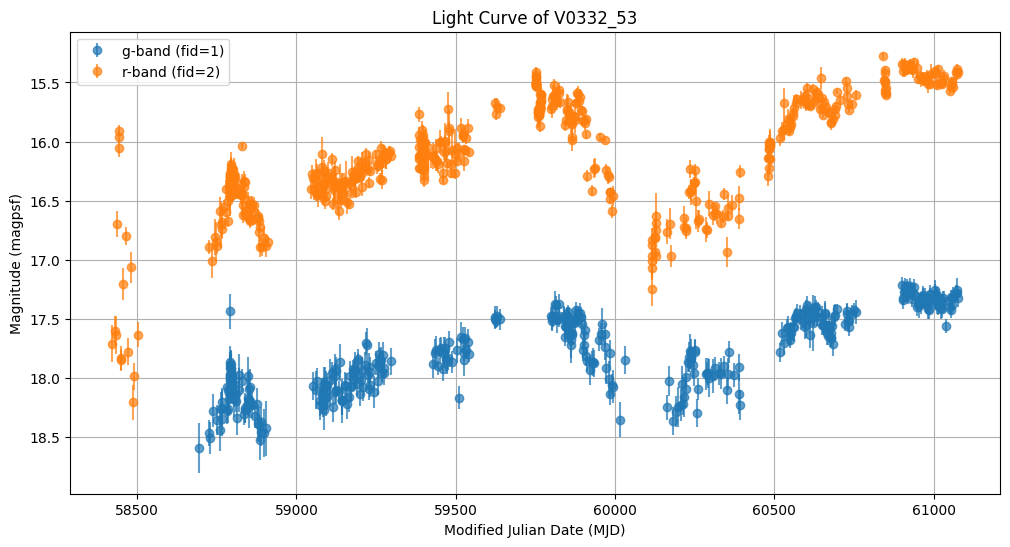

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

# Filter for g-band (fid=1)
g_band = detections_df[detections_df['fid'] == 1]
ax.errorbar(g_band['mjd'], g_band['magpsf'], yerr=g_band['sigmapsf'], fmt='o', label='g-band (fid=1)', alpha=0.7)

# Filter for r-band (fid=2)
r_band = detections_df[detections_df['fid'] == 2]
ax.errorbar(r_band['mjd'], r_band['magpsf'], yerr=r_band['sigmapsf'], fmt='o', label='r-band (fid=2)', alpha=0.7)

ax.set_xlabel('Modified Julian Date (MJD)')
ax.set_ylabel('Magnitude (magpsf)')
ax.set_title('Light Curve of V0332_53')
ax.invert_yaxis() # Magnitudes are usually plotted with brighter objects (smaller magnitudes) at the top
ax.legend()
ax.grid(True)
plt.show()

In [25]:
#crossmatch
ra=53.750,
dec=53.173,
radius = 5
catalog_name = "all"
xmatch_objects = client.catshtm_crossmatch(ra,
                                dec,
                                radius,
                                catalog_name,
                                format="pandas")
cross_match_df = pd.DataFrame(xmatch_objects)
cross_match_df

,2MASS,GAIA/DR1,GAIA/DR2,IPHAS,APASS,UCAC4,WISE,XMM,AAVSO_VSX,unWISE
A_G,NaN,NaN,1.8825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B,NaN,NaN,NaN,NaN,99.999,NaN,NaN,NaN,NaN,NaN
BV,NaN,NaN,NaN,NaN,99.999,NaN,NaN,NaN,NaN,NaN
BVerr,NaN,NaN,NaN,NaN,9.999,NaN,NaN,NaN,NaN,NaN
Berr,NaN,NaN,NaN,NaN,9.999,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
posErr,NaN,NaN,NaN,0.06,NaN,NaN,NaN,NaN,NaN,NaN
r,NaN,NaN,NaN,14.45,14.896,NaN,NaN,NaN,NaN,NaN
rErr,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
rMJD,NaN,NaN,NaN,52959.15597,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
from astropy.io import fits

hdul = fits.open(r"C:\Users\chowd\Downloads\BAT_catalog (1).fits")
hdul.info()

Filename: C:\Users\chowd\Downloads\BAT_catalog (1).fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  INPUT_CATALOG    1 BinTableHDU   1440   923R x 6C   [30A, 30A, 1J, 1E, 1E, 30A]   


In [28]:
hdul = fits.open(r"C:\Users\chowd\Downloads\BAT_catalog (1).fits")

print(hdul[1].columns)

ColDefs(
    name = 'NAME'; format = '30A'
    name = 'ALT_NAME'; format = '30A'
    name = 'CATNUM'; format = '1J'; null = -1
    name = 'RA_OBJ'; format = '1E'; unit = 'deg'
    name = 'DEC_OBJ'; format = '1E'; unit = 'deg'
    name = 'SRC_TYPE'; format = '30A'
)


In [44]:
import pandas as pd
from astropy.io import fits
import os

data = fits.getdata(r"C:\Users\chowd\Downloads\BAT_catalog (1).fits", 1)

df = pd.DataFrame(
    {
        "NAME": data["NAME"].tolist(),
        "ALT_NAME": data["ALT_NAME"].tolist(),
        "CATNUM": data["CATNUM"].tolist(),
        "RA_OBJ": data["RA_OBJ"].tolist(),
        "DEC_OBJ": data["DEC_OBJ"].tolist(),
        "SRC_TYPE": data["SRC_TYPE"].tolist(),
    }
)

df = df.astype(str).apply(lambda x: x.str.strip())

df.to_csv("swift_catalog.csv", index=False, escapechar="\\")


print(f"Total sources: {len(df)}")


print("Your file is saved in this exact folder:")
print(os.path.abspath("swift_catalog.csv"))


Total sources: 923
Your file is saved in this exact folder:
C:\Users\chowd\swift_catalog.csv


In [43]:
# Cross matching entire SWIFT catalogs using conesearch
swift_cat = pd.read_csv(r"C:\Users\chowd\Downloads\swift_source.csv")

# Convert RA and Dec to numeric, coercing errors to NaN
swift_cat['RA J2000 Degs'] = pd.to_numeric(swift_cat['RA J2000 Degs'], errors='coerce')
swift_cat['Dec J2000 Degs'] = pd.to_numeric(swift_cat['Dec J2000 Degs'], errors='coerce')

# Drop rows where RA or Dec are NaN after conversion
swift_cat = swift_cat.dropna(subset=['RA J2000 Degs', 'Dec J2000 Degs']).reset_index(drop=True)

display(swift_cat.head())

,SL,Source Name,RA J2000 Degs,Dec J2000 Degs,Alternate Name,Source Type,Today#,Yesterday#,Tenday#,Mean*,Peak*,Days*,Last Day*
0,1,QSO B0003-066,1.55789,-6.39315,NRAO 005,BL Lac,-,-,-,-,-,-,-
1,2,PSR J0007+7303,1.75600,73.05200,0FGL J0007.4+7303,Pulsar,-,-,-,0,62,4,58107 ( 2074)
2,3,QSO B0007+107,2.62919,10.97490,Mrk 1501,Sy1,-,-,-,0,0,1,1 ( 0)
3,4,QSO B0016+73,4.94078,73.45830,NaN,Quasar,-,-,-,0,0,3,1 ( 0)
4,5,IGR J00234+6141,5.74000,61.68500,V1033 Cas,CV,-,-,-,0,0,5,1 ( 0)


# ran in collab with necessary changes

In [ ]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from alerce.core import Alerce


df = pd.read_csv(r"C:\Users\chowd\Downloads\swift_source.csv")


client = Alerce()
matches = []

print("\nStarting cross-match loop:")


for index, row in df.iterrows():
    
    print(f"Checking row {index+1}/{len(df)}: {row['Source Name']}")
    
    try:
        
        ztf_matches = client.query_objects(
            survey="ztf",
            ra=float(row["RA J2000 Degs"]),
            dec=float(row["Dec J2000 Degs"]),
            radius=5
        )
      
       
        if ztf_matches is not None and len(ztf_matches) > 0:
            best = ztf_matches.iloc[0] if hasattr(ztf_matches, 'iloc') else ztf_matches[0]
            
            matches.append({
                'swift_source'  : row["Source Name"],
                'ra'            : row["RA J2000 Degs"],
                'dec'           : row["Dec J2000 Degs"],
                'ztf_found'     : True,
                'ztf_oid'       : best.get('oid', None) if isinstance(best, dict) else getattr(best, 'oid', None),
                'ztf_ra'        : best.get('meanra', None) if isinstance(best, dict) else getattr(best, 'meanra', None),
                'ztf_dec'       : best.get('meandec', None) if isinstance(best, dict) else getattr(best, 'meandec', None),
                'ztf_class'     : best.get('classxf', None) if isinstance(best, dict) else getattr(best, 'classxf', None),
                'n_ztf_matches' : len(ztf_matches)
            })
        else:
            matches.append({
                'swift_source'  : row["Source Name"],
                'ra'            : row["RA J2000 Degs"],
                'dec'           : row["Dec J2000 Degs"],
                'ztf_found'     : False,
                'ztf_oid'       : None,
                'ztf_ra'        : None,
                'ztf_dec'       : None,
                'ztf_class'     : None,
                'n_ztf_matches' : 0
            })

    except Exception as e:
        print(f"--> Error querying {row['Source Name']}: {e}")
        matches.append({
            'swift_source'  : row["Source Name"],
            'ra'            : row["RA J2000 Degs"],
            'dec'           : row["Dec J2000 Degs"],
            'ztf_found'     : False,
            'ztf_oid'       : None,
            'ztf_ra'        : None,
            'ztf_dec'       : None,
            'ztf_class'     : None,
            'n_ztf_matches' : 0
        })

    
    time.sleep(0.25)


ztf_crossmatch_df = pd.DataFrame(matches)
display(ztf_crossmatch_df)
print(f"\nFound ZTF matches for {ztf_crossmatch_df['ztf_found'].sum()} / {len(ztf_crossmatch_df)} sources")


# cross-match:MAXI source → Crossmatch with Swift → Crossmatch with ZTF except atlas

In [2]:
#cross-match:  MAXI source → Crossmatch with Swift → Crossmatch with ZTF.
import pandas as pd
from alerce.core import Alerce
import numpy as np

maxi_df = pd.read_csv(r"C:\Users\chowd\Downloads\maxi_data.csv")
swift_df = pd.read_csv(r"C:\Users\chowd\Downloads\swift_source.csv")

client = Alerce()
final_results = []


for index, row in maxi_df.iterrows():
    ra_val = float(row["RA"])
    dec_val = float(row[" Dec"])

    match_record = {
        "maxi_source": row["source name"],
        "ra": ra_val,
        "dec": dec_val,
        "swift_match_found": False,
        "swift_source_name": None,
        "ztf_found": False,
        "ztf_oid": None,
        "ztf_class": None,
        "n_ztf_matches": 0
    }

    # (within ~5 arcseconds / 0.00139 degrees)
    swift_matches = swift_df[
        (np.abs(swift_df["RA J2000 Degs"] - ra_val) < 0.00139) &
        (np.abs(swift_df["Dec J2000 Degs"] - dec_val) < 0.00139)
    ]
    if not swift_matches.empty:
        match_record.update({
            "swift_match_found": True,
            "swift_source_name": swift_matches.iloc[0]["Source Name"]
        })

    #  Check ZTF via ALeRCE API
    try:
        ztf_matches = client.query_objects(
            survey="ztf", ra=ra_val, dec=dec_val, radius=5, format="pandas"
        )
        if ztf_matches is not None and not ztf_matches.empty:
            best_ztf = ztf_matches.iloc[0]
            match_record.update({
                "ztf_found": True,
                "ztf_oid": best_ztf.get("oid"),
                "ztf_class": best_ztf.get("classxf"),
                "n_ztf_matches": len(ztf_matches)
            })
    except Exception as e:
        print(f"Error querying ZTF for {row['source name']}: {e}")

  
    final_results.append(match_record)


ztf_crossmatch_ = pd.DataFrame(final_results)
display(ztf_crossmatch_)

print(f"\nSwift matches: {ztf_crossmatch_['swift_match_found'].sum()}")
print(f"ZTF matches: {ztf_crossmatch_['ztf_found'].sum()}")

ztf_crossmatch_.to_csv('maxi_swift_ztf_crossmatch_result.csv', index=False)


,maxi_source,ra,dec,swift_match_found,swift_source_name,ztf_found,ztf_oid,ztf_class,n_ztf_matches
0,Mrk 335,1.582,20.203,False,None,True,ZTF18abwfdbb,None,1
1,WW Cet,2.853,-11.479,False,None,True,ZTF21acqojzp,None,3
2,Tycho SNR,6.308,64.144,False,None,False,None,None,0
3,V709 Cas with IGR J00291+5934,7.204,59.289,True,V709 Cas,False,None,None,0
4,IGR J00291+5934 with V709 Cas,7.263,59.572,True,IGR J00291+5934,False,None,None,0
...,...,...,...,...,...,...,...,...,...
453,NaN,NaN,NaN,False,None,False,None,None,0
454,NaN,NaN,NaN,False,None,False,None,None,0
455,NaN,NaN,NaN,False,None,False,None,None,0
456,NaN,NaN,NaN,False,None,False,None,None,0



Swift matches: 256
ZTF matches: 127
